In [1]:
import os
import sys
import gc
os.chdir('/zhome/71/c/146676/texture_tomography')
sys.path.append('/zhome/71/c/146676/texture_tomography/package/odf_mumott')
import h5py
import numpy as np
from pathlib import Path

from package.texture_tomography.operators.pfo_single_material import PFO_SINGLE, estimate_L_power
from package.texture_tomography.operators.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED

import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml

from package.odf_mumott.odftt.texture import point_groups, odfs
from package.odf_mumott.odftt import plot_tools


from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_huber_opencl import FISTAHuberOpenCL
from package.texture_tomography.gpu_live_tracker import GPUMemoryLogger
from package.texture_tomography.operators.memory_tracker import MemoryCounter
import pyopencl.array as clarray
from package.texture_tomography.multiresolution_refiner import OrientationTree, invert_grid
from package.texture_tomography.material import Material
from scipy.spatial.transform import Rotation as R

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
config_path = "configs/aluminum_config_single.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
N_theta = cfg['N_theta']
Nx = cfg['Nx']
Ny = cfg['Ny']
datapath = cfg["datapath"]
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']
filename = datapath + filename_integrated

In [3]:
from scipy.spatial.transform import Rotation as Rot

def make_rotations_from_euler(base_euler, delta_euler):
    """
    base_euler  : (3,) Euler angles in radians
    delta_euler : (3,) small increment in radians

    Returns: (4,3,3) rotation matrices
    """
    Rs = []

    for i in range(4):
        e = np.array(base_euler) + i * np.array(delta_euler)
        R = Rot.from_euler("xyz", e).as_matrix()
        Rs.append(R)

    return np.array(Rs)

base = [0.0, 0.0, 0.0]                 # identity
delta = [0.01, 0.0, 0.0]              # small rotation about x

R_array = make_rotations_from_euler(base, delta)


In [4]:
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)


path = cif_folder / filenames[0]
material = Material.from_cif(
    cif_path=path,
    wavelength_kev=wavelength_kev,
    min_two_theta=min_two_theta,
    max_two_theta=max_two_theta,
    intensity_cutoff_fraction=reflection_cutoff,
)



grid_resolution_parameter = 16      # example
kernel_sigma = 0.003            # example
sigma_levels = [kernel_sigma]      # start with single level


# grid = OrientationTree.from_hopf_fzone(
#     material.point_group_matrices,
#     grid_resolution_parameter=grid_resolution_parameter,
#     sigma_levels=sigma_levels,
# )

grid = OrientationTree.from_rotation_matrices(
    R_array,
    sigma=0.02,
)



In [5]:
material.h_vecs_normed.shape

(5, 3)

In [6]:
op = PFO_SINGLE(
        cfg = cfg,
        material=material,
        grid=grid,
        max_gb=0.2,
        verbose=True,
        normalized = True,)


0.3562848439565492
[0.15253486 0.17618918 0.24949357 0.29284424 0.3858888 ]

=== OpenCL buffer allocation summary ===
coeffs_sino_F                 : shape=(148x500x4),     1.13 MB
coeffs_sino_C                 : shape=(500x148x4),     1.13 MB
_coeffs_batch_F               : shape=(148x148x4),     0.33 MB
_basis_batch_kmax             : shape=(500x4x180x5),     6.87 MB
_basis_batch_transpose_kmax   : shape=(500x900x4),     6.87 MB
_grid_inv_kmax                : shape=(4x9),     0.00 MB
_inv_sigma2_kmax              : shape=(4),     0.00 MB
_norm_factor_kmax             : shape=(4),     0.00 MB
---------------------------------------
TOTAL GPU buffer memory:    16.33 MB



In [7]:
queue = op.queue


y_gpu = clarray.zeros( queue, (N_rot, Nx, N_theta*N_chi), dtype=np.float32, order="C")


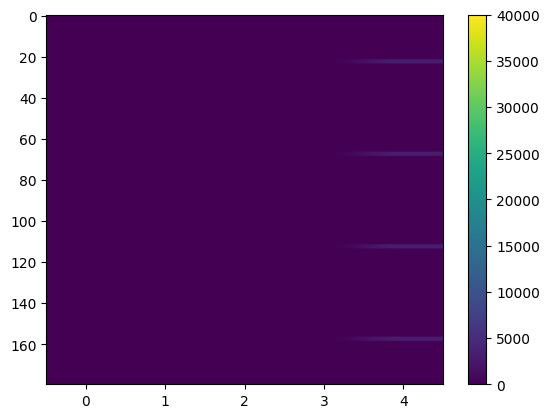

In [8]:
x_gpu = clarray.zeros(
    queue,
    (Nx, Ny, op.K),
    dtype=np.float32,
    order="F",
)
x_gpu[:,:,0] = 1.0
op.direct_cl(x_gpu, y_gpu)
y_cpu = y_gpu.get()
plt.imshow(y_cpu[0,0].reshape((N_chi, N_theta)),aspect='auto')
plt.clim([0,40000])
plt.colorbar()
plt.show()

In [9]:
import matplotlib.pyplot as plt
import pstats
import cProfile
import numpy as np
from xrd_simulator.polycrystal import Polycrystal
from xrd_simulator.mesh import TetraMesh
from xrd_simulator.phase import Phase
from xrd_simulator.detector import Detector
from xrd_simulator.beam import Beam
from xrd_simulator.motion import RigidBodyMotion
from xfab import tools
from scipy.spatial.transform import Rotation as Rot
import pyFAI

def test_image(rotation, angle_range):
    def R_x(a):
        ca, sa = np.cos(a), np.sin(a)
        return np.array([[1, 0, 0],
                        [0, ca, -sa],
                        [0, sa,  ca]])

    def R_y(a):
        ca, sa = np.cos(a), np.sin(a)
        return np.array([[ ca, 0, sa],
                        [  0, 1,  0],
                        [-sa, 0, ca]])

    def R_z(a):
        ca, sa = np.cos(a), np.sin(a)
        return np.array([[ca, -sa, 0],
                        [sa,  ca, 0],
                        [ 0,   0, 1]])

    def detector_from_poni_simple(dist_m, poni1_m, poni2_m,
                                pixel_size_um, n_rows, n_cols):

        dist_um  = dist_m  * 1e6
        poni1_um = poni1_m * 1e6
        poni2_um = poni2_m * 1e6

        width_y = n_cols * pixel_size_um
        height_z = n_rows * pixel_size_um

        # beam center on detector plane
        beam_center = np.array([dist_um, poni2_um, poni1_um])

        # detector origin corner
        corner0 = beam_center - np.array([0, width_y/2, height_z/2])
        corner1 = corner0 + np.array([0, width_y, 0])
        corner2 = corner0 + np.array([0, 0, height_z])

        return corner0, corner1, corner2

    pixel_size_um = 172.0
    n_cols = 1475
    n_rows = 1679

    dist = 0.2448925755721187
    poni1 = 0.15044219476863135
    poni2 = 0.1280762471337877
    rot1 = 0.0020848796460703864
    rot2 = -0.0025411427389760133
    rot3 = 0.0

    det_corner_0, det_corner_1, det_corner_2 = detector_from_poni_simple(
        dist, poni1, poni2,
        pixel_size_um, n_rows, n_cols
    )


    vertical_halfsize = n_rows/2*pixel_size_um
    horizontal_halfsize = n_cols/2*pixel_size_um
    det_corner_0=np.array([dist*1e6, -horizontal_halfsize, -vertical_halfsize])
    det_corner_1=np.array([dist*1e6, horizontal_halfsize, -vertical_halfsize])
    det_corner_2=np.array([dist*1e6, -horizontal_halfsize, vertical_halfsize])
    print(det_corner_0, det_corner_1, det_corner_2)


    detector = Detector(
        pixel_size_z=pixel_size_um,
        pixel_size_y=pixel_size_um,
        det_corner_0=det_corner_0,
        det_corner_1=det_corner_1,
        det_corner_2=det_corner_2
    )


    coord = np.array([[-0.125, -0.125, -0.125],
    [ 0.375, -0.125, -0.125],
    [-0.125,  0.375, -0.125],
    [-0.125, -0.125,  0.375]
    ])*100

    enod = np.array([[0, 1, 2, 3]], dtype=int)

    mesh = TetraMesh.generate_mesh_from_vertices(coord, enod)

    print('nelm:', mesh.number_of_elements)

    unit_cell = [4.04958, 4.04958, 4.04958, 90., 90., 90.]
    sgname = 'Fm-3m'  # Al
    phases = [Phase(unit_cell=unit_cell, sgname = sgname)]
    print(phases)

    #R = np.array([[1,0,0],[0,1,0],[0,0,1]])
    
    R = rotation
    orientation = np.array([R], dtype=float)      # shape (1,3,3)
    element_phase_map = np.zeros((mesh.number_of_elements,)).astype(int)


    w = pixel_size_um  # full field beam
    dist_um = dist * 1e6
    beam_vertices = np.array([
        [-dist_um, -w, -w],
        [-dist_um, w, -w],
        [-dist_um, w, w],
        [-dist_um, -w, w],
        [dist_um, -w, -w],
        [dist_um, w, -w],
        [dist_um, w, w],
        [dist_um, -w, w]])
    wavelength = 0.3562957
    xray_propagation_direction = np.array([1, 0, 0])
    polarization_vector = np.array([0, 1, 0])
    beam = Beam(
        beam_vertices,
        xray_propagation_direction,
        wavelength,
        polarization_vector)

    difference = angle_range[1] - angle_range[0]
    rotation_angle = difference * np.pi / 180.
    rotation_axis = np.array([0, 0, 1])
    translation = np.array([0, 0, 0])
    axis = np.array([0,0,1], dtype=float)
    axis = axis / np.linalg.norm(axis)

    initial = angle_range[0]
    theta0 = initial * np.pi / 180.0

    R0 = Rot.from_rotvec(axis * theta0).as_matrix()
    orientation[0] = R0 @ orientation[0] 
    polycrystal = Polycrystal(mesh, orientation, strain=np.zeros(
        (3, 3)), phases=phases, element_phase_map=element_phase_map)


    motion = RigidBodyMotion(rotation_axis, rotation_angle, translation)

    polycrystal.diffract(beam, detector, motion)

    pr = cProfile.Profile()
    pr.enable()
    diffraction_pattern = detector.render(
        frames_to_render=0,
        lorentz=False,
        polarization=False,
        structure_factor=False,
        method='project')
    pr.disable()
    pr.dump_stats('tmp_profile_dump')
    ps = pstats.Stats('tmp_profile_dump').strip_dirs().sort_stats('cumtime')
    ps.print_stats(20)

    # diffraction_pattern[ diffraction_pattern<=0 ] = 1
    # diffraction_pattern = np.log(diffraction_pattern)
    # plt.imshow(diffraction_pattern, cmap='jet')
    # plt.colorbar()
    # plt.title("Hits: " + str(len(detector.frames[0])))
    # plt.show()






    def two_theta_to_q(two_theta, wavelength):
        # PyFAI uses 1/nm for q. Poni wavelength is in m
        return (4*np.pi/wavelength) * np.sin(0.5 * two_theta)


    poni_path = "/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/raw_data_aluminum_detector/poni_no_rot.poni"
    ai = pyFAI.load(poni_path)
    N_chi = 180
    width_two_theta = 0.02
    peaks_two_theta = np.array([0.15253486, 0.17618918, 0.24949356 , 0.29284422, 0.38588877])
    q_lower = two_theta_to_q(peaks_two_theta-width_two_theta, wavelength=ai.wavelength*1e9)
    q_upper = two_theta_to_q(peaks_two_theta+width_two_theta, wavelength=ai.wavelength*1e9)
    q_min = q_lower.min()
    q_max = q_upper.max()
    N_theta_total = 100
    N_rings = 5

    I_rings = np.zeros((1, N_chi, N_rings), dtype=np.float32)

    mask_list = []
    delta_q = (q_max-q_min)/(N_theta_total)
    q = np.linspace(q_min+delta_q/2, q_max-delta_q/2, N_theta_total)

    for i_ring in range(N_rings):
        mask = (q >= q_lower[i_ring]) & (q < q_upper[i_ring])
        mask_list.append(mask)

    print(diffraction_pattern.shape)
    img = np.ascontiguousarray(diffraction_pattern.astype(np.float32))
    res = ai.integrate2d(
                        img,
                        npt_rad=N_theta_total,
                        npt_azim=N_chi,
                        radial_range=(q_min, q_max),
                        method=("no", "csr", "cython"),
                        )
    I = res.intensity
    for i_ring in range(N_rings):
        I_rings[0,:,i_ring] = I[:,mask_list[i_ring]].sum(axis=1)

    # plt.figure()
    # plt.imshow(I_rings[0], cmap='jet', aspect='auto')
    # plt.title("Hits: " + str(len(detector.frames[0])))
    # plt.colorbar()
    # plt.show()
    return I_rings[0]


In [21]:
k = 0
angles = np.arange(3)
I_rings = []
for i in range(2):
    print(angles[i])
    I_rings.append(test_image(grid.nodes[k].R.as_matrix(), [0,179.9]))
I_rings = np.stack(I_rings)

0
[ 244892.57557212 -126850.         -144394.        ] [ 244892.57557212  126850.         -144394.        ] [ 244892.57557212 -126850.          144394.        ]
nelm: 1
Rendering 244 scattering volumes unto the detector      |████████████████████████████████████████| 100.0%
Wed Jan 14 11:24:48 2026    tmp_profile_dump

         41309 function calls in 0.358 seconds

   Ordered by: cumulative time
   List reduced from 109 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.358    0.358 detector.py:103(render)
        1    0.001    0.001    0.341    0.341 detector.py:209(_render_and_convolve)
        1    0.005    0.005    0.270    0.270 detector.py:243(_apply_point_spread_function)
        1    0.001    0.001    0.265    0.265 _signaltools.py:1666(convolve2d)
        1    0.264    0.264    0.264    0.264 {built-in method scipy.signal._sigtools._convolve2d}
      244    0.002    0.000    0.055    0.000 de

In [22]:
x_gpu = clarray.zeros(
    queue,
    (Nx, Ny, op.K),
    dtype=np.float32,
    order="F",
)
x_gpu[:,:,k] = 1.0
op.direct_cl(x_gpu, y_gpu)
y_cpu = y_gpu.get()
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def plot_i(i):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(I_rings[i], aspect='auto', interpolation='nearest')
    plt.clim([0,1000])
    plt.title(f"I_rings[{i}]")
    plt.colorbar()

    plt.subplot(1,2,2)
    plt.imshow(np.log(1000+np.sum(y_cpu[:1,0],axis=0).reshape((N_chi, N_theta))), aspect='auto', interpolation='nearest')
    plt.title("y_cpu[0,0] reshaped")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(min=0, max=15, step=1, value=0, description="i")

widgets.interact(plot_i, i=slider)

interactive(children=(IntSlider(value=0, description='i', max=15), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_i(i)>

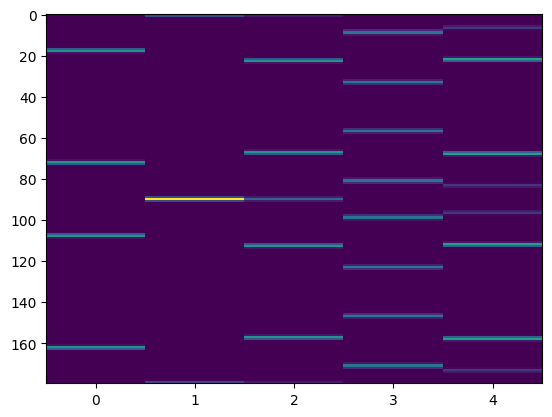

In [24]:
plt.imshow(np.sum(y_cpu[0:250],axis=0)[0].reshape((N_chi, N_theta)), aspect='auto', interpolation='nearest')

In [20]:
import matplotlib.pyplot as plt
import ipywidgets as widgets

def plot_overlay(i, j):
    plt.figure(figsize=(6,5))

    # bottom layer (y_cpu)
    plt.imshow(
        y_cpu[j,0].reshape((N_chi, N_theta)),
        aspect='auto',
        cmap='gray'
    )

    # top layer (I_rings)
    plt.imshow(
        I_rings[i],
        aspect='auto',
        cmap='jet',
        alpha=0.7
    )

    plt.title(f"Overlay: I_rings[{i}]  |  y_cpu[{j},0]")
    plt.tight_layout()
    plt.show()

slider_i = widgets.IntSlider(min=0, max=I_rings.shape[0]-1, value=0, description="i")
slider_j = widgets.IntSlider(min=0, max=y_cpu.shape[0]-1, value=0, description="j")

widgets.interact(plot_overlay, i=slider_i, j=slider_j)


interactive(children=(IntSlider(value=0, description='i', max=1), IntSlider(value=0, description='j', max=499)…

<function __main__.plot_overlay(i, j)>

In [128]:
import numpy as np
from scipy.spatial.transform import Rotation as Rot

def d_cubic(a, hkl):
    h,k,l = hkl
    return a / np.sqrt(h*h + k*k + l*l)

def bragg_theta(lam, d):
    # returns theta in radians if feasible, else None
    s = lam / (2*d)
    if s <= 0 or s >= 1:
        return None
    return np.arcsin(s)

def crosses_bragg_in_scan(a, lam, hkl, axis, ang_min_deg, ang_max_deg, n=2001):
    """
    Very simple gating: checks if the angle between rotated plane normal and beam
    crosses the Bragg condition. This is necessary but not sufficient for detector hit,
    but it already removes lots of PF peaks.
    """
    theta = bragg_theta(lam, d_cubic(a, hkl))
    print(2*theta)
    if theta is None:
        return False

    # For a plane with normal n, Bragg occurs when angle between beam and plane is (90°-theta),
    # i.e. beam-to-normal angle is (90°- (90°-theta))?? careful:
    # plane normal makes angle alpha with beam; Bragg when alpha = 90° - theta.
    alpha_target = np.pi/2 - theta

    angs = np.linspace(ang_min_deg, ang_max_deg, n) * np.pi/180
    beam = np.array([1.,0.,0.])  # if beam along +x in your lab frame

    # plane normal in crystal frame: take n = hkl/|hkl|, then rotate by orientation
    n0 = np.array(hkl, dtype=float)
    n0 /= np.linalg.norm(n0)

    # orientation is identity here (ODF at I)
    # scan rotation about axis in lab:
    axis = np.array(axis, dtype=float)
    axis /= np.linalg.norm(axis)

    # compute alpha(ang) = angle between rotated normal and beam
    alphas = []
    for ang in angs:
        R = Rot.from_rotvec(axis*ang).as_matrix()
        n_lab = R @ n0
        alphas.append(np.arccos(np.clip(n_lab @ beam, -1, 1)))
    alphas = np.array(alphas)

    # did we come close to target?
    return np.min(np.abs(alphas - alpha_target)) < (1.0*np.pi/180)  # tolerance 0.2°


In [134]:
a = 4.04958        # Å
lam = 0.3562957        # Å  (your simulation wavelength)
axis = [0,0,1]         # your rocking axis
ang_min, ang_max = 0, 20  # degrees (try ±10, ±20)

hkls_to_test = [(1,1,1),(2,0,0),(2,2,0),(3,1,1),(3,3,1)]
for hkl in hkls_to_test:
    print(hkl, crosses_bragg_in_scan(a, lam, hkl, axis, ang_min, ang_max))


0.15253951497387466
(1, 1, 1) False
0.17619456532724995
(2, 0, 0) False
0.24950120258408195
(2, 2, 0) False
0.29285320721141705
(3, 1, 1) False
0.3859006728961231
(3, 3, 1) False
